# Capstone Session 7

This notebook is generated from the copied `Capstone_Session_7.pdf` directions and the staged `CC GENERAL.csv` dataset.

## Objective

Cluster credit card users using PCA and K-means while preserving the requirement order from the copied PDF.

In [ ]:
from pathlib import Path
import json
import sys
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

IS_COLAB = 'google.colab' in sys.modules
GITHUB_REPO_OWNER = 'FrancisBurnet'
GITHUB_REPO_NAME = 'francisburnet'
GITHUB_REPO_BRANCH = 'main'
CAPSTONE_ROOT = Path('Incremental Capstones/Machine Learning Using Python/Capstone Session 7')
DATASET_FILENAME = 'CC GENERAL.csv'


def build_raw_github_url(relative_path: Path) -> str:
    encoded_path = quote(relative_path.as_posix(), safe='/')
    return (
        f"https://raw.githubusercontent.com/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}/"
        f"{GITHUB_REPO_BRANCH}/{encoded_path}"
    )


def resolve_capstone_dir() -> Path | None:
    current = Path.cwd().resolve()
    capstone_parts = CAPSTONE_ROOT.parts
    for candidate in [current, *current.parents]:
        if len(candidate.parts) >= len(capstone_parts) and candidate.parts[-len(capstone_parts):] == capstone_parts:
            return candidate
        nested_candidate = candidate / CAPSTONE_ROOT
        if nested_candidate.exists():
            return nested_candidate
    return None


CAPSTONE_DIR = resolve_capstone_dir()
DATASET_URL = build_raw_github_url(CAPSTONE_ROOT / DATASET_FILENAME)

if CAPSTONE_DIR is not None:
    OUTPUT_ROOT = CAPSTONE_DIR
    OUTPUT_MODE = 'permanent capstone outputs'
    OUTPUT_DISPLAY = (CAPSTONE_ROOT / 'outputs').as_posix()
else:
    runtime_root = Path('/content/capstone-session-7-runtime') if IS_COLAB else Path.cwd().resolve() / 'capstone-session-7-runtime'
    OUTPUT_ROOT = runtime_root
    OUTPUT_MODE = 'runtime scratch outputs; export final artifacts back into the capstone outputs folder'
    OUTPUT_DISPLAY = 'capstone-session-7-runtime/outputs'

OUTPUTS_DIR = (OUTPUT_ROOT / 'outputs').resolve()
PLOTS_DIR = OUTPUTS_DIR / 'plots'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

print('Runtime:', 'Google Colab' if IS_COLAB else 'Notebook runtime')
print('Capstone artifact path:', CAPSTONE_ROOT.as_posix())
print('Dataset source:', DATASET_URL)
print('Output mode:', OUTPUT_MODE)
print('Output target:', OUTPUT_DISPLAY)

In [ ]:
df = pd.read_csv(DATASET_URL)
display(df.head())
print('Dataset source used:', DATASET_URL)
print('Shape:', df.shape)
print(df.isna().sum().sort_values(ascending=False).head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Shape: (8950, 18)
MINIMUM_PAYMENTS     313
CREDIT_LIMIT           1
BALANCE                0
CUST_ID                0
BALANCE_FREQUENCY      0
dtype: int64


In [3]:
working_df = df.drop(columns=['CUST_ID']).copy()
for column in working_df.columns:
    if working_df[column].isna().any():
        working_df[column] = working_df[column].fillna(working_df[column].median())
print('Remaining null values:', int(working_df.isna().sum().sum()))

Remaining null values: 0


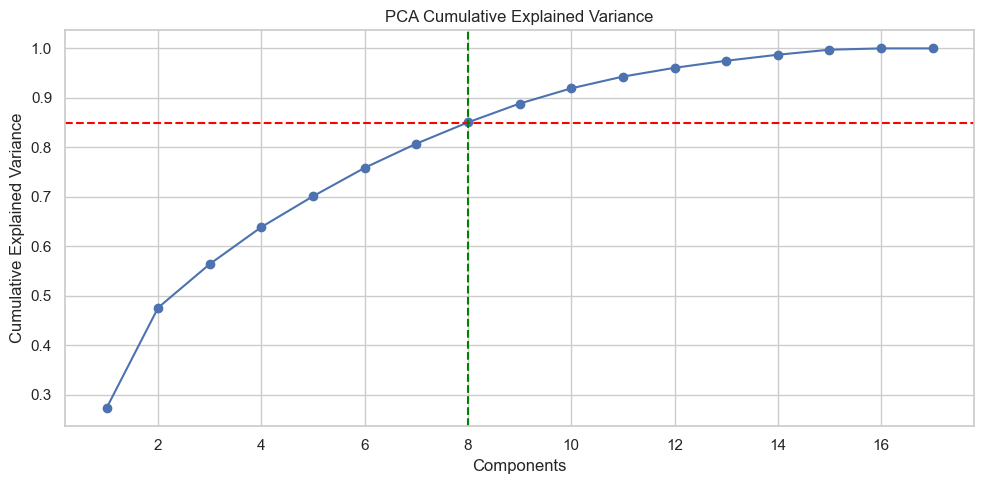

8

In [4]:
scaler = StandardScaler()
scaled = scaler.fit_transform(working_df)
pca_full = PCA()
pca_full.fit(scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)
components_needed = int(np.argmax(explained >= 0.85) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(explained) + 1), explained, marker='o')
ax.axhline(0.85, color='red', linestyle='--')
ax.axvline(components_needed, color='green', linestyle='--')
ax.set_title('PCA Cumulative Explained Variance')
ax.set_xlabel('Components')
ax.set_ylabel('Cumulative Explained Variance')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'pca_explained_variance.png', dpi=150)
plt.show()
plt.close(fig)
components_needed

In [5]:
pca_two = PCA(n_components=2, random_state=42)
pca_features = pca_two.fit_transform(scaled)
covariance = pd.DataFrame(pca_full.get_covariance(), index=working_df.columns, columns=working_df.columns)
covariance.to_csv(OUTPUTS_DIR / 'session_7_covariance_matrix.csv')
upper_triangle = covariance.where(np.triu(np.ones(covariance.shape), k=1).astype(bool))
top_pair = upper_triangle.stack().abs().sort_values(ascending=False).index[0]
{'top_covariance_pair': top_pair, 'value': float(covariance.loc[top_pair[0], top_pair[1]])}

{'top_covariance_pair': ('PURCHASES', 'ONEOFF_PURCHASES'),
 'value': 0.9169470108951325}

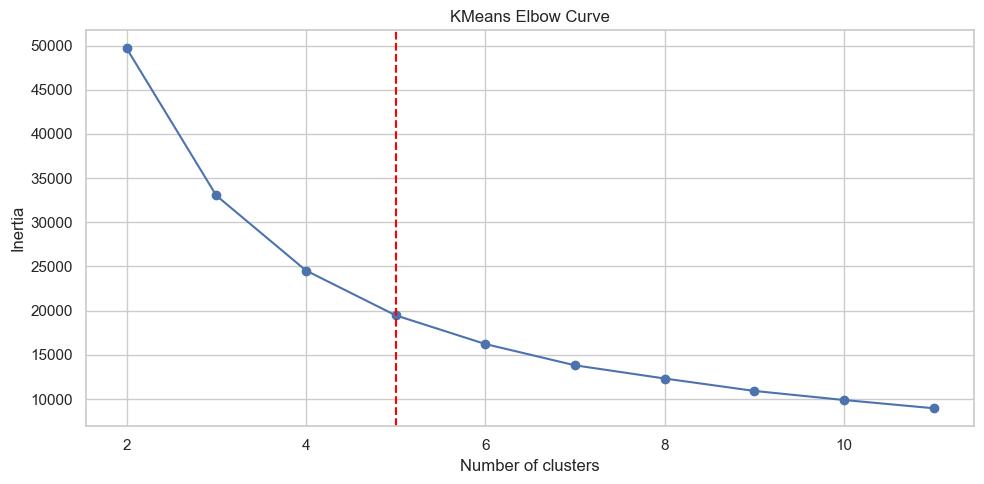

5

In [6]:
cluster_range = list(range(2, 12))
inertias = []
for n_clusters in cluster_range:
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    model.fit(pca_features)
    inertias.append(float(model.inertia_))

x = np.array(cluster_range)
y = np.array(inertias)
line_start = np.array([x[0], y[0]])
line_end = np.array([x[-1], y[-1]])
line_vector = line_end - line_start
line_vector = line_vector / np.linalg.norm(line_vector)
points = np.column_stack([x, y])
distances = []
for point in points:
    vector = point - line_start
    projection = line_start + np.dot(vector, line_vector) * line_vector
    distances.append(np.linalg.norm(point - projection))
ideal_clusters = int(x[int(np.argmax(distances))])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cluster_range, inertias, marker='o')
ax.axvline(ideal_clusters, color='red', linestyle='--')
ax.set_title('KMeans Elbow Curve')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Inertia')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'kmeans_elbow.png', dpi=150)
plt.show()
plt.close(fig)
ideal_clusters

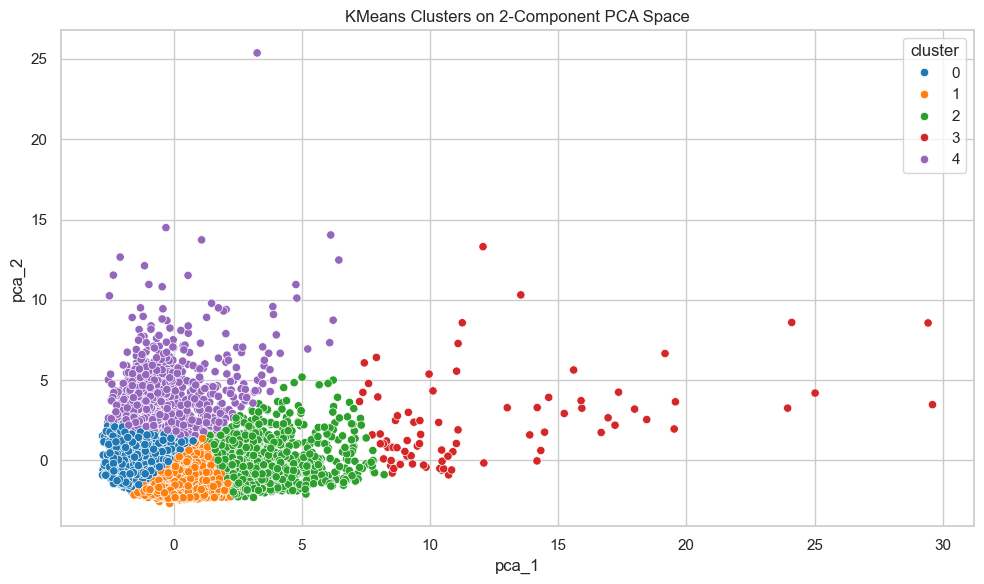

,pca_1,pca_2,cluster
0,-1.683649,-1.072241,0
1,-1.134085,2.509150,4
2,0.969395,-0.383577,1
3,-0.888220,0.004648,0
4,-1.600021,-0.683795,0


In [7]:
final_model = KMeans(n_clusters=ideal_clusters, random_state=42, n_init=20)
clusters = final_model.fit_predict(pca_features)
cluster_df = pd.DataFrame({'pca_1': pca_features[:, 0], 'pca_2': pca_features[:, 1], 'cluster': clusters})
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x='pca_1', y='pca_2', hue='cluster', palette='tab10', ax=ax)
ax.set_title('KMeans Clusters on 2-Component PCA Space')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'cluster_scatter.png', dpi=150)
plt.show()
plt.close(fig)
cluster_sizes = cluster_df['cluster'].value_counts().sort_index().to_dict()
cluster_df.head()

In [8]:
cluster_df.to_csv(OUTPUTS_DIR / 'session_7_cluster_assignments.csv', index=False)
summary = {
    'dataset_shape': list(df.shape),
    'filled_missing_values': {'MINIMUM_PAYMENTS': int(df['MINIMUM_PAYMENTS'].isna().sum()), 'CREDIT_LIMIT': int(df['CREDIT_LIMIT'].isna().sum())},
    'components_for_85_percent_variance': components_needed,
    'top_covariance_pair': {'columns': list(top_pair), 'value': float(covariance.loc[top_pair[0], top_pair[1]])},
    'cluster_range': cluster_range,
    'inertias': inertias,
    'ideal_clusters': ideal_clusters,
    'cluster_sizes': cluster_sizes,
}
with open(OUTPUTS_DIR / 'session_7_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'dataset_shape': [8950, 18],
 'filled_missing_values': {'MINIMUM_PAYMENTS': 313, 'CREDIT_LIMIT': 1},
 'components_for_85_percent_variance': 8,
 'top_covariance_pair': {'columns': ['PURCHASES', 'ONEOFF_PURCHASES'],
  'value': 0.9169470108951325},
 'cluster_range': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 'inertias': [49682.0510019688,
  33031.5387265398,
  24544.39226676279,
  19474.98317130457,
  16227.989956199026,
  13819.288934398468,
  12324.670804661473,
  10919.28112800173,
  9894.139885607852,
  8959.441443049795],
 'ideal_clusters': 5,
 'cluster_sizes': {0: 3502, 1: 3247, 2: 1038, 3: 81, 4: 1082}}